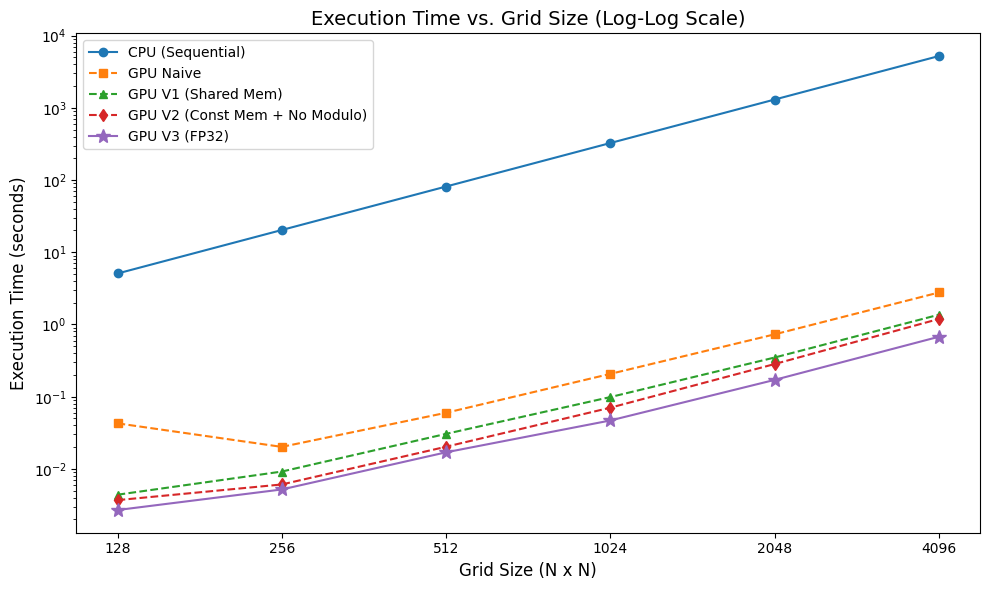

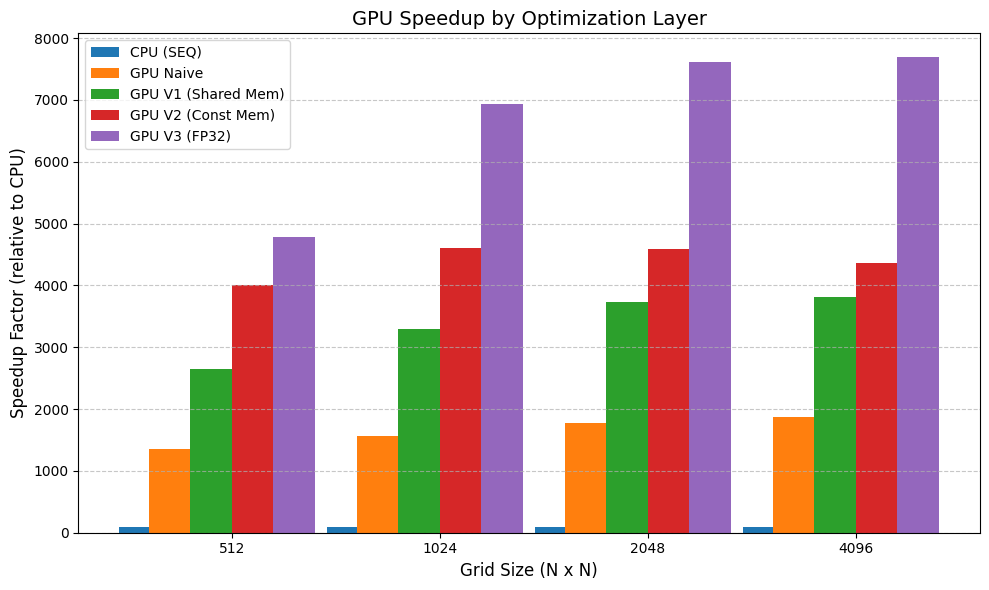

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data for Tile Size 16
N = np.array([128, 256, 512, 1024, 2048, 4096])
T_seq = np.array([5.0795, 20.3176, 81.2717, 325.1207, 1300.6583, 5203.7136])
T_naive = np.array([0.0428, 0.0202, 0.0599, 0.2071, 0.7305, 2.7718])
T_v1 = np.array([0.0044, 0.0092, 0.0306, 0.0989, 0.3488, 1.3655])
T_v2 = np.array([0.0037, 0.0061, 0.0203, 0.0705, 0.2833, 1.1927])
T_v3 = np.array([0.0027, 0.0052, 0.0170, 0.0469, 0.1710, 0.6765])

# Calculate Speedups relative to CPU
S_naive = T_seq / T_naive
S_v1 = T_seq / T_v1
S_v2 = T_seq / T_v2
S_v3 = T_seq / T_v3

# ---------------------------------------------------------
# Plot 1: Log-Log Execution Time vs. Grid Size
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(N, T_seq, marker='o', linestyle='-', label='CPU (Sequential)')
plt.plot(N, T_naive, marker='s', linestyle='--', label='GPU Naive')
plt.plot(N, T_v1, marker='^', linestyle='--', label='GPU V1 (Shared Mem)')
plt.plot(N, T_v2, marker='d', linestyle='--', label='GPU V2 (Const Mem + No Modulo)')
plt.plot(N, T_v3, marker='*', linestyle='-', markersize=10, label='GPU V3 (FP32)')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Grid Size (N x N)', fontsize=12)
plt.ylabel('Execution Time (seconds)', fontsize=12)
plt.title('Execution Time vs. Grid Size (Log-Log Scale)', fontsize=14)
plt.xticks(N, [str(n) for n in N])
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('execution_time_loglog.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 2: Grouped Bar Chart of Speedups (for N >= 512)
# ---------------------------------------------------------
# Filter for larger grid sizes where GPU saturation is visible
large_indices = [2, 3, 4, 5] # Corresponds to N = 512, 1024, 2048, 4096
N_large = N[large_indices]

x = np.arange(len(N_large))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 2.2*width, 100, width, label='CPU (SEQ)')
plt.bar(x - 1.5*width, S_naive[large_indices], width, label='GPU Naive')
plt.bar(x - 0.5*width, S_v1[large_indices], width, label='GPU V1 (Shared Mem)')
plt.bar(x + 0.5*width, S_v2[large_indices], width, label='GPU V2 (Const Mem)')
plt.bar(x + 1.5*width, S_v3[large_indices], width, label='GPU V3 (FP32)')

plt.xlabel('Grid Size (N x N)', fontsize=12)
plt.ylabel('Speedup Factor (relative to CPU)', fontsize=12)
plt.title('GPU Speedup by Optimization Layer', fontsize=14)
plt.xticks(x, [str(n) for n in N_large])
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('speedup_barchart.png', dpi=300)
plt.show()

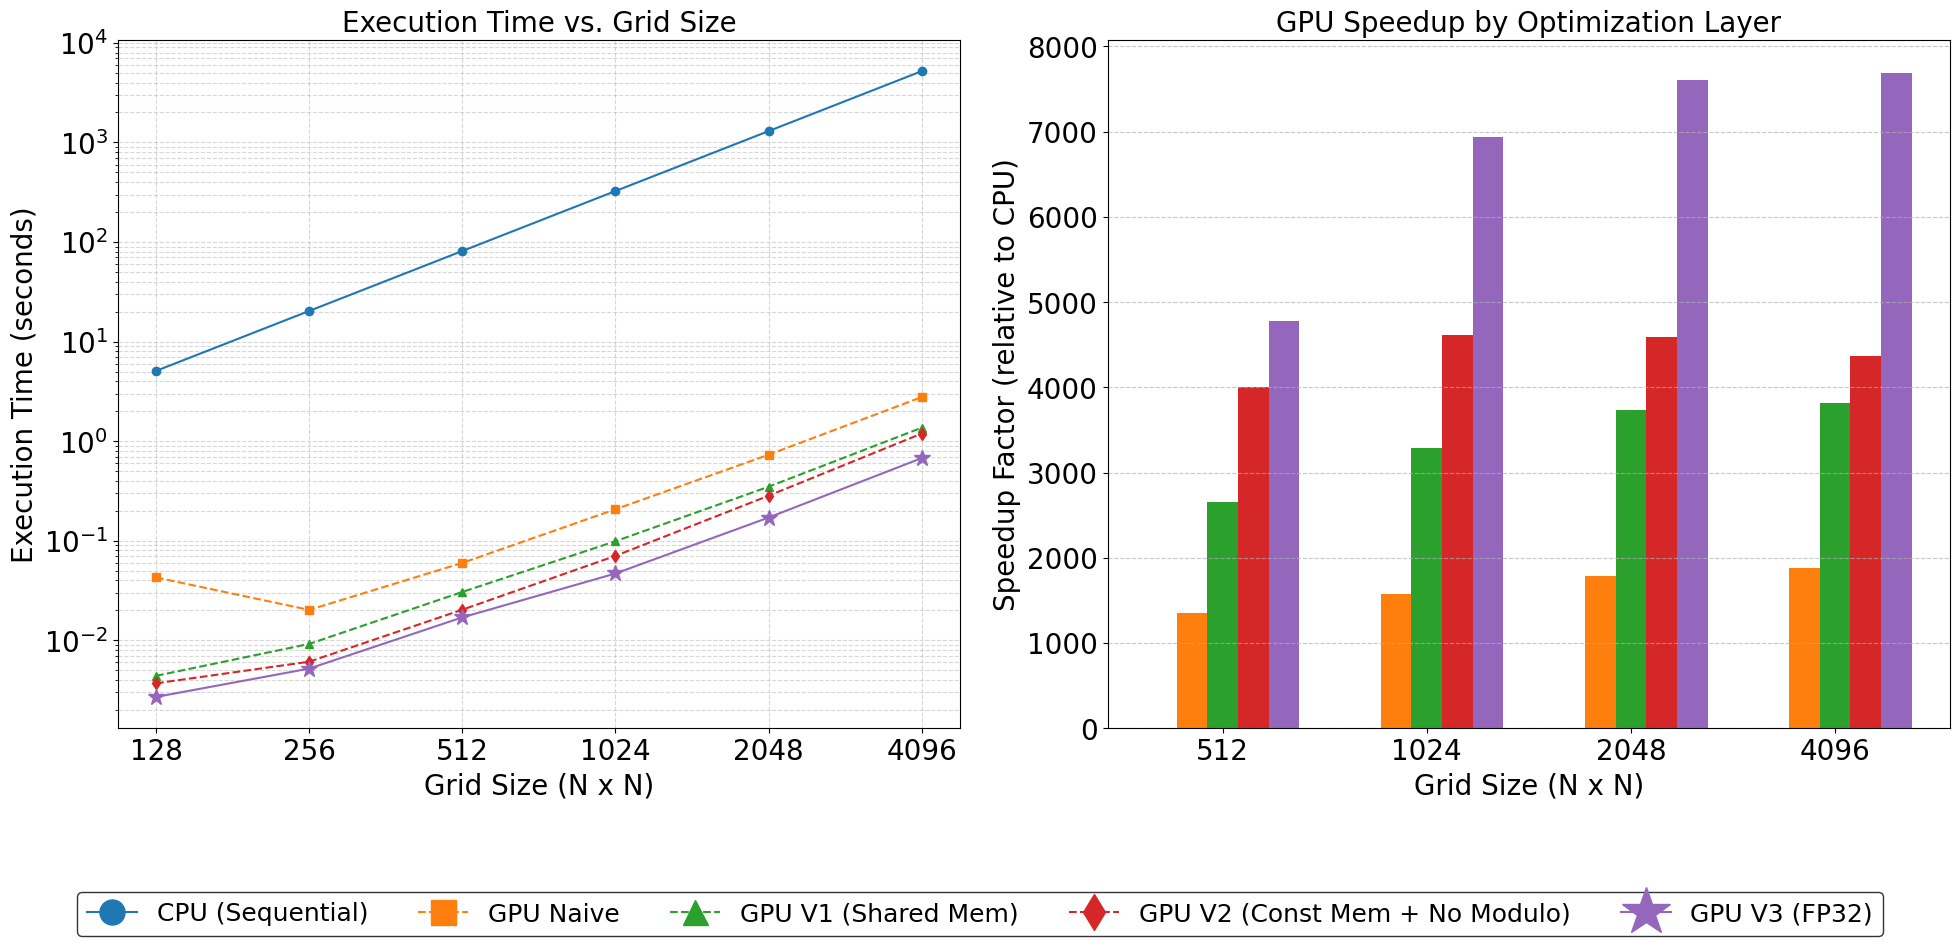

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Increase default font sizes globally (makes numbers and labels bigger)
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20
})

# Data for Tile Size 16
N = np.array([128, 256, 512, 1024, 2048, 4096])
T_seq = np.array([5.0795, 20.3176, 81.2717, 325.1207, 1300.6583, 5203.7136])
T_naive = np.array([0.0428, 0.0202, 0.0599, 0.2071, 0.7305, 2.7718])
T_v1 = np.array([0.0044, 0.0092, 0.0306, 0.0989, 0.3488, 1.3655])
T_v2 = np.array([0.0037, 0.0061, 0.0203, 0.0705, 0.2833, 1.1927])
T_v3 = np.array([0.0027, 0.0052, 0.0170, 0.0469, 0.1710, 0.6765])

# Calculate Speedups relative to CPU
S_naive = T_seq / T_naive
S_v1 = T_seq / T_v1
S_v2 = T_seq / T_v2
S_v3 = T_seq / T_v3

# Filter for larger grid sizes where GPU saturation is visible
large_indices = [2, 3, 4, 5] # Corresponds to N = 512, 1024, 2048, 4096
N_large = N[large_indices]

# Setup Figure with 1 row, 2 columns side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# ---------------------------------------------------------
# Plot 1: Log-Log Execution Time vs. Grid Size (Left)
# ---------------------------------------------------------
ax1.plot(N, T_seq, marker='o', linestyle='-', label='CPU (Sequential)')
ax1.plot(N, T_naive, marker='s', linestyle='--', label='GPU Naive')
ax1.plot(N, T_v1, marker='^', linestyle='--', label='GPU V1 (Shared Mem)')
ax1.plot(N, T_v2, marker='d', linestyle='--', label='GPU V2 (Const Mem + No Modulo)')
ax1.plot(N, T_v3, marker='*', linestyle='-', markersize=12, label='GPU V3 (FP32)')

ax1.set_xscale('log', base=2)
ax1.set_yscale('log')
ax1.set_xlabel('Grid Size (N x N)')
ax1.set_ylabel('Execution Time (seconds)')
ax1.set_title('Execution Time vs. Grid Size')
ax1.set_xticks(N)
ax1.set_xticklabels([str(n) for n in N])
ax1.grid(True, which="both", ls="--", alpha=0.5)

# ---------------------------------------------------------
# Plot 2: Grouped Bar Chart of Speedups (Right)
# ---------------------------------------------------------
x = np.arange(len(N_large))
width = 0.15 # Adjusted to fit 5 bars perfectly side-by-side

# Added bars spaced cleanly around 'x'
ax2.bar(x - 2*width, 1, width, label='CPU (Sequential)') # Set to 1x speedup instead of 100
ax2.bar(x - width, S_naive[large_indices], width, label='GPU Naive')
ax2.bar(x, S_v1[large_indices], width, label='GPU V1 (Shared Mem)')
ax2.bar(x + width, S_v2[large_indices], width, label='GPU V2 (Const Mem + No Modulo)')
ax2.bar(x + 2*width, S_v3[large_indices], width, label='GPU V3 (FP32)')

ax2.set_xlabel('Grid Size (N x N)')
ax2.set_ylabel('Speedup Factor (relative to CPU)')
ax2.set_title('GPU Speedup by Optimization Layer')
ax2.set_xticks(x)
ax2.set_xticklabels([str(n) for n in N_large])
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# ---------------------------------------------------------
# Single Shared Legend (Boxed)
# ---------------------------------------------------------
handles, labels = ax1.get_legend_handles_labels()

# Set frameon=True and added edgecolor to create a visible box
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.1), 
           ncol=5, frameon=True, edgecolor='black', fancybox=True, 
           fontsize=18, markerscale=3)

# Maintain the layout spacing for the legend
plt.tight_layout(rect=[0, 0.15, 1, 1])

# bbox_inches='tight' ensures the legend is kept fully inside the exported image
plt.savefig('combined_performance_plots.png', dpi=300, bbox_inches='tight')
plt.show()